In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



In [92]:
np.random.seed(42)

n_samples = 10000  # total dataset size

data = {
    "tutor_rating": np.random.uniform(2.5, 5.0, n_samples),
    "rating_count": np.random.randint(1, 100, n_samples),
    "experience_level": np.random.randint(1, 6, n_samples),
    "sessions": np.random.randint(1, 20, n_samples),
    "avg_improvement": np.random.uniform(-1.5, 3.0, n_samples),
    "subject": np.random.choice(
        ["Math", "Physics", "English", "Computer_Science"],
        n_samples
    )
}

df = pd.DataFrame(data)




In [93]:
def success_probability(row):
    score=((row["avg_improvement"] * 0.4) +
           (row["tutor_rating"] * 0.3) +
           (row["sessions"] * 0.2)+ 
           (row['experience_level']*0.1))
    prob=1/(1+np.exp(-(score -5)))
    return prob

In [96]:
df["success_prob"] = df.apply(success_probability, axis=1)
df['success']=( df["success_prob"] > 0.5).astype(int)

noise_indices=np.random.choice(df.index, size=int(0.1 * len(df)), replace=False )
df.loc[noise_indices, 'success'] = 1- df.loc[noise_indices, 'success']
    

print(df.head())

   tutor_rating  rating_count  experience_level  sessions  avg_improvement  \
0      3.436350            55                 1         4         0.460373   
1      4.876786            96                 4        18        -1.238679   
2      4.329985            36                 1        18         2.470806   
3      3.996646            37                 1         9        -0.073526   
4      2.890047            14                 5         3         1.391072   

            subject  success_prob  success  
0  Computer_Science      0.052903        0  
1  Computer_Science      0.491892        0  
2           Physics      0.728558        1  
3              Math      0.126704        0  
4  Computer_Science      0.077518        0  


In [97]:
df=pd.get_dummies(df)

In [98]:
X= df.drop(columns=['success'])
y= df['success']

In [99]:
# for documentation purposes
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [120]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight = 'balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [121]:
y_pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8953333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      2251
           1       0.91      0.64      0.75       749

    accuracy                           0.90      3000
   macro avg       0.90      0.81      0.84      3000
weighted avg       0.90      0.90      0.89      3000



In [122]:
feat_imp=pd.DataFrame({"Features": X_train.columns, "Importance":model.feature_importances_}).sort_values(by='Importance', ascending=False)

In [123]:
feat_imp

,Features,Importance
5,success_prob,0.411745
3,sessions,0.160927
4,avg_improvement,0.145279
0,tutor_rating,0.116555
1,rating_count,0.094959
2,experience_level,0.033966
9,subject_Physics,0.009776
7,subject_English,0.009170
8,subject_Math,0.009031
6,subject_Computer_Science,0.008594


In [124]:
df.head()

,tutor_rating,rating_count,experience_level,sessions,avg_improvement,success_prob,success,subject_Computer_Science,subject_English,subject_Math,subject_Physics
0,3.436350,55,1,4,0.460373,0.052903,0,True,False,False,False
1,4.876786,96,4,18,-1.238679,0.491892,0,True,False,False,False
2,4.329985,36,1,18,2.470806,0.728558,1,False,False,False,True
3,3.996646,37,1,9,-0.073526,0.126704,0,False,False,True,False
4,2.890047,14,5,3,1.391072,0.077518,0,True,False,False,False


In [125]:
scores=cross_val_score(model,X_train, y_train, cv=5)
print('Cross-validation scores',scores)
print('Mean CV accuracy', scores.mean())

Cross-validation scores [0.90642857 0.89785714 0.89357143 0.89214286 0.91      ]
Mean CV accuracy 0.9


In [126]:
param_grid = {'n_estimators':[50,100,200], 'max_depth':[None, 5,10,20], 'min_samples_split':[2,5,10]}
GS= GridSearchCV(model, param_grid, cv=5, scoring='accuracy',n_jobs=1)
GS.fit(X_train, y_train)
print('Best Parameters:',GS.best_params_)
print('Best CV Score:',GS.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.9014285714285715


In [133]:
best_model= GS.best_estimator_
y_pred= best_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8963333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      2251
           1       0.91      0.65      0.76       749

    accuracy                           0.90      3000
   macro avg       0.90      0.81      0.85      3000
weighted avg       0.90      0.90      0.89      3000



In [128]:
df['success'].value_counts()


success
0    7547
1    2453
Name: count, dtype: int64

In [130]:
joblib.dump (best_model, "tutoring_model.pkl")


['tutoring_model.pkl']

In [131]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[2204,   47],
       [ 264,  485]])

<function matplotlib.pyplot.show(close=None, block=None)>

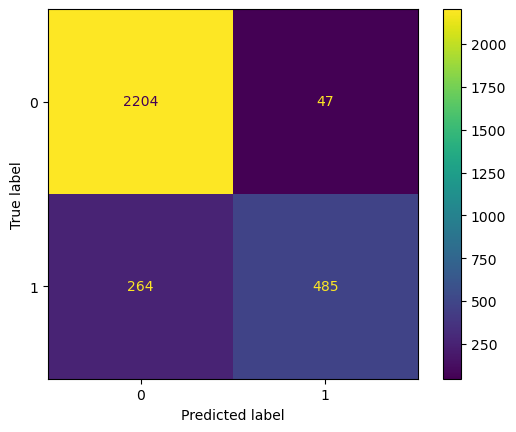

In [132]:
play = ConfusionMatrixDisplay(confusion_matrix=cm)
play.plot()
plt.show